
# Modelo RBC de Economia Aberta com Política Fiscal

**Autoria:** Grupo FISLAC – Banco Interamericano de Desarrollo. **Colaboração:** Ministério da Fazenda do Brasil. **Data:** Janeiro de 2026.


In [1]:
using Pkg
Pkg.add("Dynare")      # Execute apenas se ainda não instalou
Pkg.add("AxisArrays")  # Execute apenas se ainda não instalou

using Dynare
using Serialization
using DataFrames
using XLSX
using Plots
using AxisArrays

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Statistics ───── v1.11.1
   Installed DelimitedFiles ─ v1.9.1
   Installed MbedTLS_jll ──── v2.28.0+0
  Installing 1 artifacts
   Installed artifact MbedTLS                  2.1 MiB
    Updating `~/.julia/environments/v1.8/Project.toml`
  [9e88b42a] ~ Serialization ⇒ v1.11.0
    Updating `~/.julia/environments/v1.8/Manifest.toml`
  [8bb1440f] + DelimitedFiles v1.9.1
  [b429d917] - DensityInterface v0.4.0
  [33e6dc65] - MKL v0.6.3
  [f5f7c340] - PATHSolver v1.7.9
  [46dd5b70] - Pardiso v0.5.7
  [10745b16] + Statistics v1.11.1
⌃ [c8ffd9c3] ~ MbedTLS_jll v2.28.0+0 ⇒ v2.28.0+0
  [0dad84c5] ↑ ArgTools v1.1.1 ⇒ v1.1.2
  [56f22d72] ~ Artifacts ⇒ v1.11.0
  [2a0f44e3] ~ Base64 ⇒ v1.11.0
  [ade2ca70] ~ Dates ⇒ v1.11.0
  [8ba89e20] ~ Distributed ⇒ v1.11.0
  [f43a241f] ↑ Downloads v1.6.0 ⇒ v1.7.0
  [7b1f6079] ~ FileWatching ⇒ v1.11.0
  [9fa8497b] ~ Future ⇒ v1.11.0
  [b77e0a4c] ~ InteractiveUt

In [2]:
mod = read("RBC_abierto.mod", String)
println(mod)


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                   Banco Interamericano de Desarrollo                    %
%                                                                         %
%            Modelo RBC de economia aberta com política fiscal            %
%                           Janeiro de 2026                               %
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

%--------------------------------------------------------------------------
% 1. Definição de variáveis
%--------------------------------------------------------------------------

% Variáveis endógenas

var
    c          (long_name='Consumo privado') 
    rk         (long_name='Retorno do capital')
    n          (long_name='Trabalho')
    k          (long_name='Capital privado') 
    x          (long_name='Investimento privado')
    y          (long_name='Produto') 
    w          (long_name='Taxa de salário') 
    rb         (long_n

In [3]:
println("Iniciando Dynare...")
using Dynare
m = @dynare("RBC_abierto.mod");
println("Dynare finalizado!")

Iniciando Dynare...


Dynare version: 0.9.18
2026-01-20T13:01:37.194: Starting @dynare RBC_abierto.mod
["RBC_abierto.mod", "language=julia", "json=compute"]
Dynare preprocessor version: 6.4.0+0
2026-01-20T13:01:37.305: End of preprocessing


Starting preprocessing of the model file ...
Found 36 equation(s).
Evaluating expressions...
Computing static model derivatives (order 1).
Normalizing the static model...
Finding the optimal block decomposition of the static model...
13 block(s) found:
  11 recursive block(s) and 2 simultaneous block(s).
  the largest simultaneous block has 10 equation(s)
                                 and 8 feedback variable(s).
Computing dynamic model derivatives (order 1).
Normalizing the dynamic model...
Finding the optimal block decomposition of the dynamic model...
8 block(s) found:
  6 recursive block(s) and 2 simultaneous block(s).
  the largest simultaneous block has 11 equation(s)
                                 and 10 feedback variable(s).
JSON written after Computing step.
Preprocessing completed.



2026-01-20T13:01:38.174: Start parse_statements!
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31


Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:44
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:31
Exception while generating log record in module Dynare at /home/vscode/.julia/packages/Dynare/AZQL4/src/dynare_table.jl:12
Exception while 

2026-01-20T13:01:51.928: End parse_statements!
2026-01-20T13:01:51.929: End parser


Dynare finalizado!


In [6]:

irf_rstar = m.results.model_results[1].irfs[Symbol("Choque de taxa de juro internacional")];

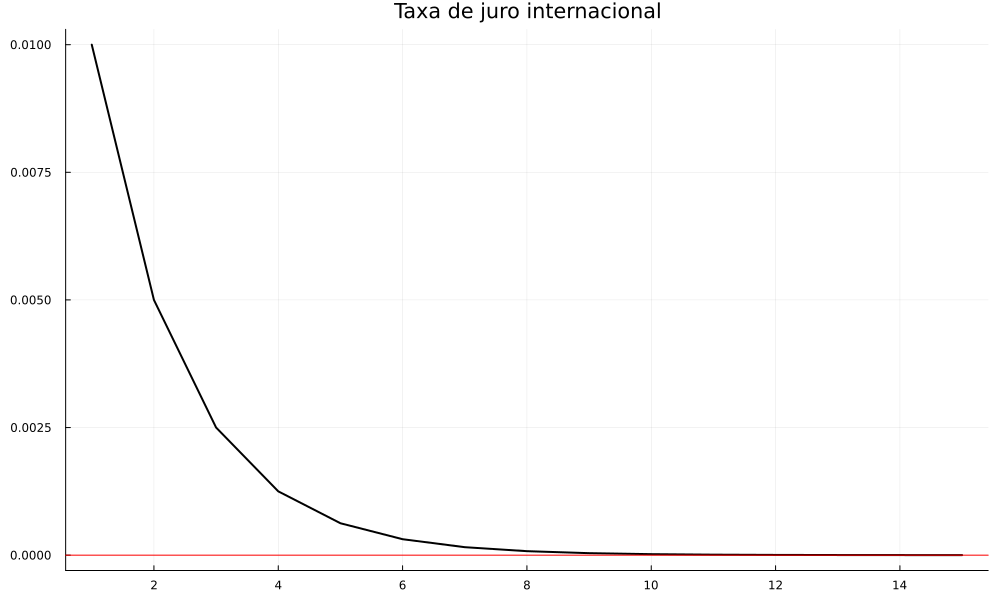

"/workspaces/julia_codespace_template/Sessão 6/RBC_rstar_IRFs.png"

In [7]:
vars = [Symbol("Taxa de juro internacional")]
titles = ["Taxa de juro internacional"] 

p = plot(layout = (1, 1), size = (1000, 600))

for (i, v) in enumerate(vars)
    plot!(p[i], irf_rstar[1:15, v],
          color = :black,
          lw = 2,
          title = titles[i],
          ylabel = "",
          legend = false)
    hline!(p[i], [0], color = :red, lw = 1, linestyle = :solid)
end


display(p)
savefig("RBC_rstar_IRFs.png")


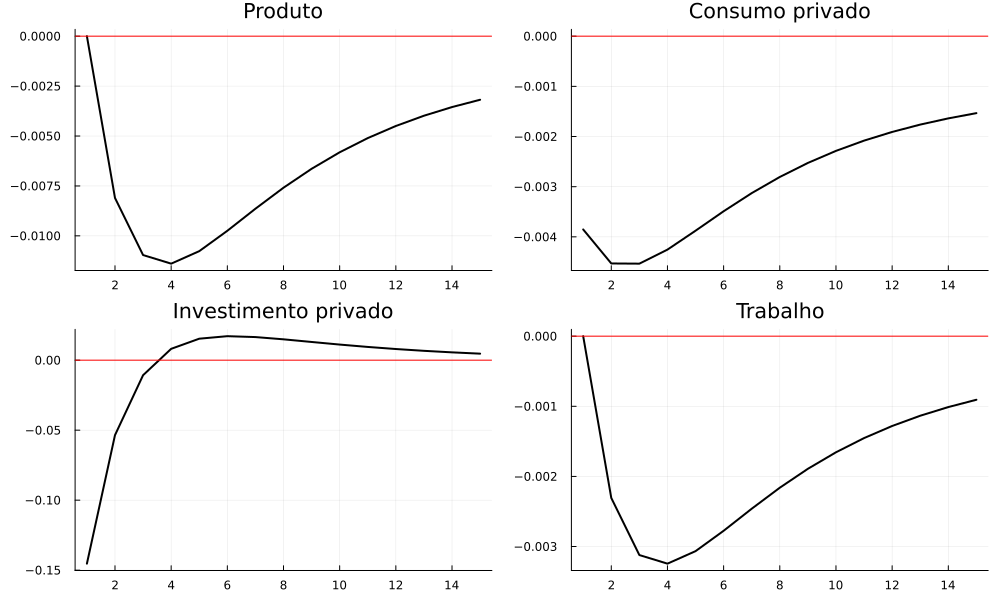

"/workspaces/julia_codespace_template/Sessão 6/RBC_rstar_agregados_IRFs.png"

In [8]:
vars = [Symbol("Produto"), Symbol("Consumo privado"), Symbol("Investimento privado"), Symbol("Trabalho")]
titles = ["Produto", "Consumo privado", "Investimento privado", "Trabalho"] 

p = plot(layout = (2, 2), size = (1000, 600))

for (i, v) in enumerate(vars)
    plot!(p[i], irf_rstar[1:15, v],
          color = :black,
          lw = 2,
          title = titles[i],
          ylabel = "",
          legend = false)
    hline!(p[i], [0], color = :red, lw = 1, linestyle = :solid)
end


display(p)
savefig("RBC_rstar_agregados_IRFs.png")

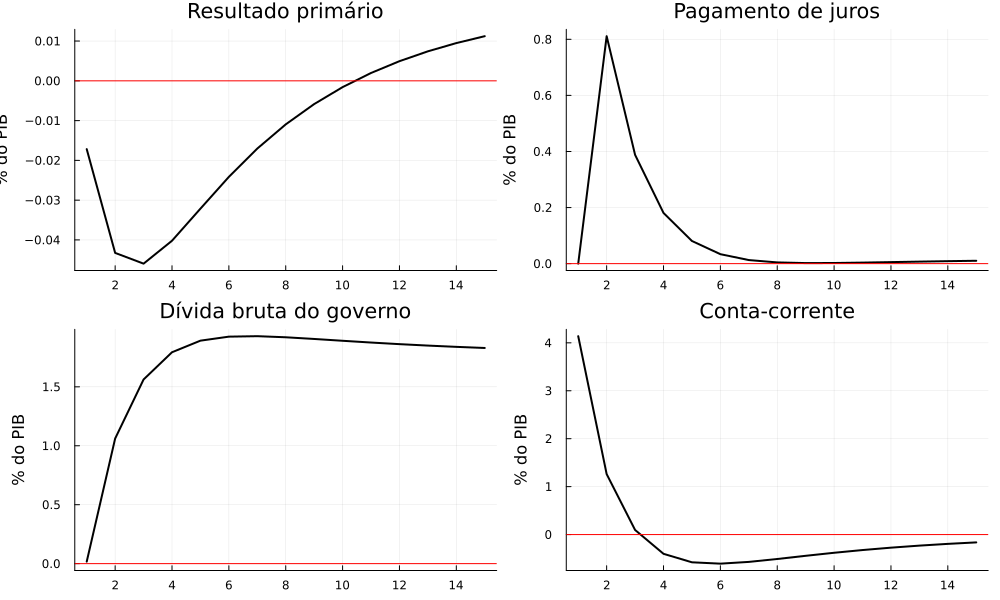

"/workspaces/julia_codespace_template/Sessão 6/RBC_rstar_fiscal_IRFs.png"

In [9]:
vars = [ Symbol("Resultado primário como proporção do PIB"), Symbol("Pagamento de juros como proporção do PIB"), Symbol("Dívida como proporção do PIB"), 
        Symbol("Conta-corrente como proporção do PIB")]
titles = ["Resultado primário","Pagamento de juros","Dívida bruta do governo","Conta-corrente",] 

p = plot(layout = (2, 2), size = (1000, 600))

for (i, v) in enumerate(vars)
    plot!(p[i], irf_rstar[1:15, v].*100,
          color = :black,
          lw = 2,
          title = titles[i],
          ylabel = "% do PIB",
          legend = false)
    hline!(p[i], [0], color = :red, lw = 1, linestyle = :solid)
end


display(p)
savefig("RBC_rstar_fiscal_IRFs.png")